<a href="https://colab.research.google.com/github/korsahike/CS135-Assign1/blob/main/VR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**UNEMPLOYMENT AND INFLATION IN THE US** <br>
Question: What is the relationship between unemployment rate and inflation in the United States </br>


**Relative Concepts** </br>
These concepts draws on concepts from: </br>
- Machine Learning  
- Econometrics
- Intermediate Macroeconomics

Which stems from:
- Time Series Analysis  </br>
- Linear Regression </br>
- Philips Curve

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

LOAD THE DATA

In [ ]:
df = pd.read_csv("/content/fredgraph.csv")
df.head()

,observation_date,UNRATE,CORESTICKM159SFRBATL
0,1948-01-01,3.4,NaN
1,1948-02-01,3.8,NaN
2,1948-03-01,4.0,NaN
3,1948-04-01,3.9,NaN
4,1948-05-01,3.5,NaN


Convert the date and time to pandas datetime

In [ ]:
df["observation_date"] = pd.to_datetime(df["observation_date"])
df

,observation_date,UNRATE,CORESTICKM159SFRBATL
0,1948-01-01,3.4,NaN
1,1948-02-01,3.8,NaN
2,1948-03-01,4.0,NaN
3,1948-04-01,3.9,NaN
4,1948-05-01,3.5,NaN
...,...,...,...
931,2025-08-01,4.3,3.428096
932,2025-09-01,4.4,3.326080
933,2025-10-01,NaN,3.094288
934,2025-11-01,4.5,2.951403


Information about the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   observation_date      936 non-null    datetime64[ns]
 1   UNRATE                935 non-null    float64       
 2   CORESTICKM159SFRBATL  696 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 22.1 KB


Total null values

In [ ]:
df.isnull().sum()

,0
observation_date,0
UNRATE,1
CORESTICKM159SFRBATL,240


New dataframe with dropped missing values

In [ ]:
df = df.copy()
df = df.dropna()
df_new = np.round(df,2)
df_new

,observation_date,UNRATE,CORESTICKM159SFRBATL
240,1968-01-01,3.7,3.65
241,1968-02-01,3.8,3.67
242,1968-03-01,3.7,4.14
243,1968-04-01,3.5,4.16
244,1968-05-01,3.5,4.09
...,...,...,...
930,2025-07-01,4.3,3.42
931,2025-08-01,4.3,3.43
932,2025-09-01,4.4,3.33
934,2025-11-01,4.5,2.95


In [ ]:
df_up = df.drop(columns="observation_date")
np.round(df_up,2)

,UNRATE,CORESTICKM159SFRBATL
240,3.7,3.65
241,3.8,3.67
242,3.7,4.14
243,3.5,4.16
244,3.5,4.09
...,...,...
930,4.3,3.42
931,4.3,3.43
932,4.4,3.33
934,4.5,2.95


Summary Statistics

In [ ]:
df_up.describe()

,UNRATE,CORESTICKM159SFRBATL
count,695.000000,695.000000
mean,5.971655,4.311739
std,1.747081,2.658466
min,3.400000,0.663868
25%,4.700000,2.469023
50%,5.700000,3.375760
75%,7.200000,5.149713
max,14.800000,15.774167


In [ ]:
df_up.corr()

,UNRATE,CORESTICKM159SFRBATL
UNRATE,1.000000,0.124785
CORESTICKM159SFRBATL,0.124785,1.000000


Philips type

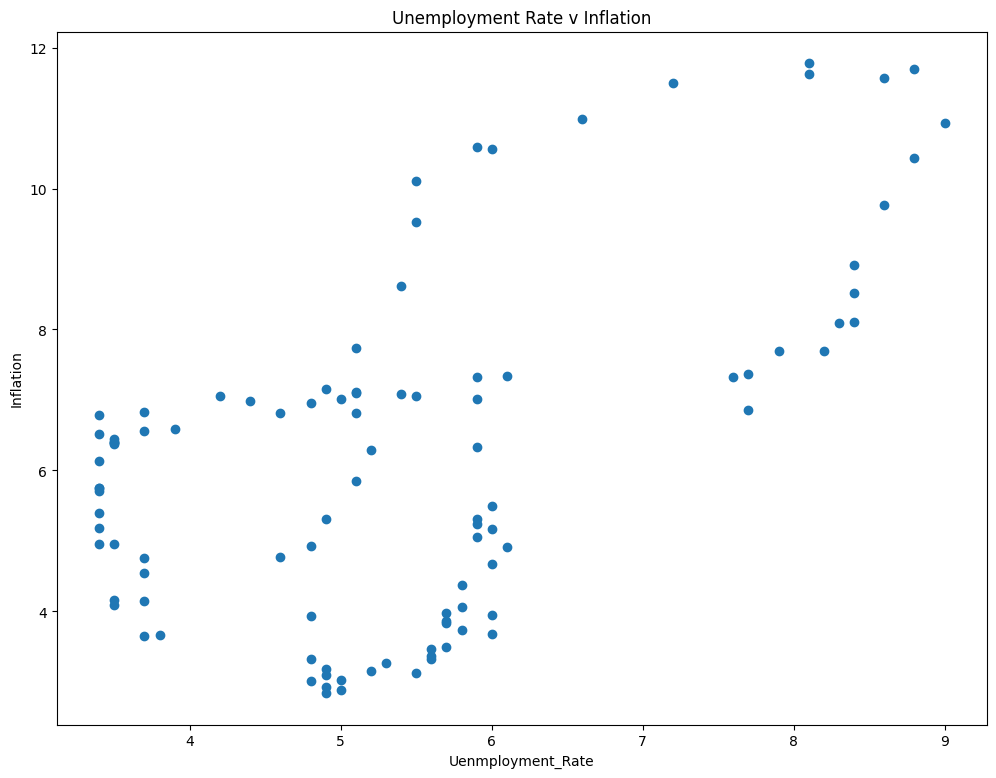

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(df_new["UNRATE"][:100],df_new["CORESTICKM159SFRBATL"][:100],marker="o")
plt.title("Unemployment Rate v Inflation")
plt.xlabel("Uenmployment_Rate")
plt.ylabel("Inflation")
plt.show()

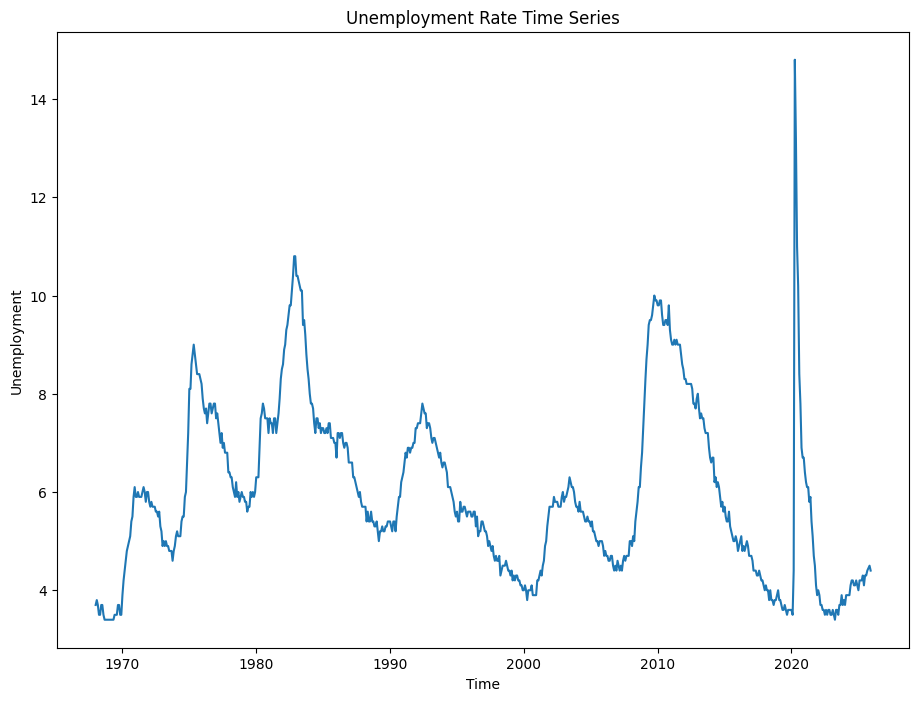

In [ ]:
plt.figure(figsize=(11,8))
plt.plot(df_new["observation_date"],df_new["UNRATE"])
plt.title("Unemployment Rate Time Series")
plt.xlabel("Time")
plt.ylabel("Unemployment")
plt.show()

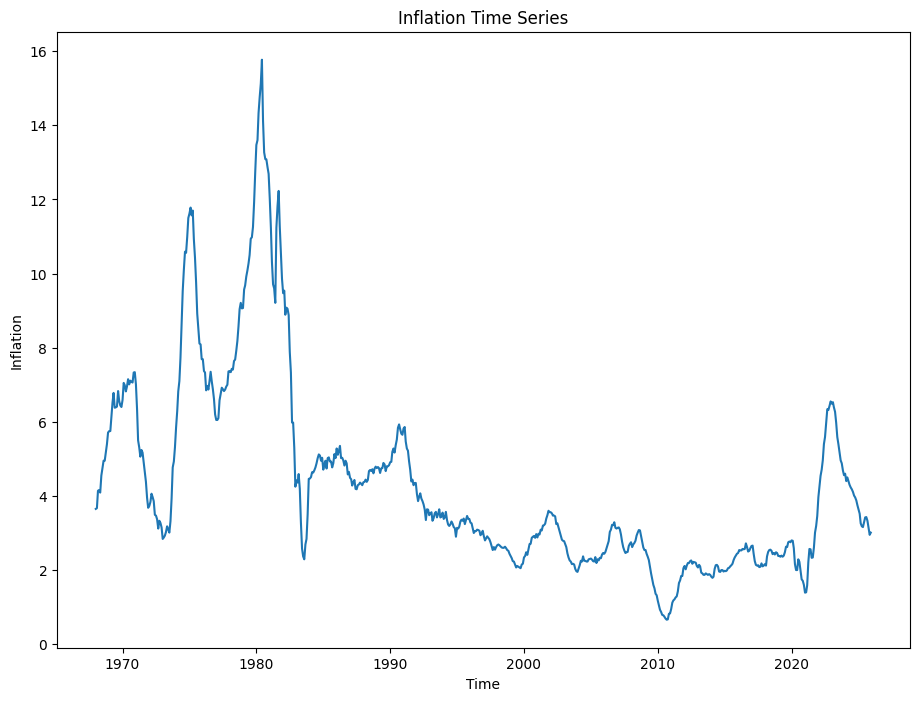

In [ ]:
plt.figure(figsize=(11,8))
plt.plot(df_new["observation_date"],df_new["CORESTICKM159SFRBATL"])
plt.title("Inflation Time Series")
plt.xlabel("Time")
plt.ylabel("Inflation")
plt.show()

In [ ]:
x = df_new[["UNRATE"]]
y = df_new["CORESTICKM159SFRBATL"]

In [ ]:
model = LinearRegression()
model.fit(x,y)
y_pred = model.predict(x)
B1 = model.coef_[0]
B0 = model.intercept_
mse = mean_squared_error(y,y_pred)
rmse = np.sqrt(mse)
line = f"y = {B0:.2f} + {B1:.2f}x"
print(line,"\nMSE:",f"{mse:.2f}","\nRMSE:",f"{rmse:.2f}")

y = 3.18 + 0.19x 
MSE: 6.95 
RMSE: 2.64


In [ ]:
residuals = pd.DataFrame({
    "y_actual":y,
    "y_pred":y_pred,
    "error":[(yi-yn) for yi,yn in zip(y,y_pred)]
})
residuals

,y_actual,y_pred,error
240,3.65,3.880446,-0.230446
241,3.67,3.899430,-0.229430
242,4.14,3.880446,0.259554
243,4.16,3.842478,0.317522
244,4.09,3.842478,0.247522
...,...,...,...
930,3.42,3.994350,-0.574350
931,3.43,3.994350,-0.564350
932,3.33,4.013334,-0.683334
934,2.95,4.032318,-1.082318


/tmp/ipython-input-470373746.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


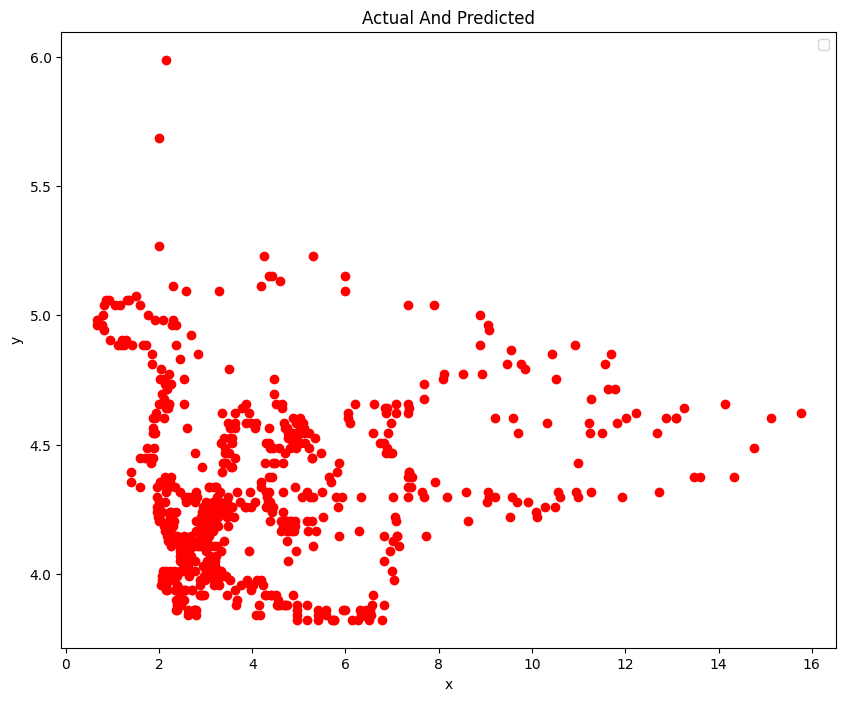

In [ ]:
plt.figure(figsize=(10,8))
plt.title("Actual And Predicted")
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(y,y_pred,color="red")
plt.show()

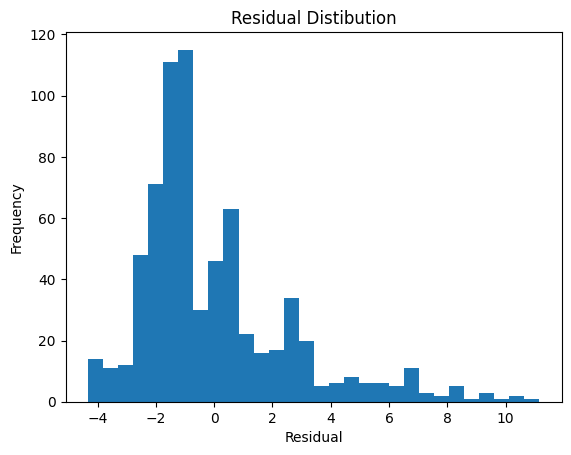

In [ ]:
plt.hist(residuals["error"],bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distibution")
plt.show()